__Tutorial de Sympy y Networkx__

Tutorial sobre las operaciones con matrices utilizando la librería SymPy de Python y Networkx para crear diagramas de transición. 

__Sympy__ <br>
Primero se debe importar todo de la librería SymPy, la cual permite realizar los cálculos simbólicos en Python.

In [7]:
from sympy import *

__1.- Vectores__  <br>
Un vector denota una cantidad física que tiene magnitud y orientación en un determinado sistema de referencia. En SymPy, los vectores se pueden definir mediante la clase __Matrix__ del módulo matrices. Para crear un vector, a la clase __Matrix__ le pasamos como argumento una lista.
Por ejemplo, definimos dos vectores $\vec{u}$ y $\vec{v}$, dados por:
$$
\vec{u} =
\begin{pmatrix}
1 \\
2
\end{pmatrix}, 
\qquad
\vec{v} =
\begin{pmatrix}
3 \\
4
\end{pmatrix}
$$

In [8]:
u=Matrix([1,2])
v=Matrix([3,4])

Una suma y resta vectorial se pueden ejecutar con los operadores ya conocidos + y -

In [10]:
u+v

Matrix([
[4],
[6]])

In [11]:
u-v

Matrix([
[-2],
[-2]])

La magnitud de un vector se calcula usando el método __norm__ 

In [12]:
u.norm()

sqrt(5)

El producto escalar de dos vectores se puede calcular utilizando el método __dot__

In [13]:
u.dot(v)

11

 Los vectores en SymPy también pueden contener expresiones simbólicas y funcionan de la misma manera las operaciones anteriores, por ejemplo:

In [20]:
a,b=symbols("a,b")
w=Matrix([a**3+b**3,b-a**2])
w

Matrix([
[a**3 + b**3],
[  -a**2 + b]])

In [21]:
w+u

Matrix([
[a**3 + b**3 + 1],
[  -a**2 + b + 2]])

__2.- Matrices__ <br>
Las matrices son arreglos rectangulares de números o cantidades simbólicas. En SymPy, se definen utilizando la clase __Matrix__, pasándole como argumentos una lista de listas, donde cada sublista corresponde a una fila de la matriz.

In [22]:
Matrix([[2,8,-3], [5,6,1], [-1,2,8]])

Matrix([
[ 2, 8, -3],
[ 5, 6,  1],
[-1, 2,  8]])

__2.1.- Suma y resta con matrices__ <br>
- Para una suma de matrices se usa el operador +
- Para una multiplicación de matrices se usa el operador *

In [27]:
A=Matrix([[2,-5,1], [-10,7,3], [-3,2,4]])
B=Matrix([[1,6,5],[3,-1,1],[2,2,0]])
A+B

Matrix([
[ 3, 1, 6],
[-7, 6, 4],
[-1, 4, 4]])

In [28]:
A*B

Matrix([
[-11,  19,   5],
[ 17, -61, -43],
[ 11, -12, -13]])

__2.2.- Multiplicación de vectores con matrices__ <br>
La multiplicacion de vectores y matrices en SymPy se realiza utilizando la clase __Matrix__ y el operador __*__ para el producto, los vectores se definen como matrices columna o fila y el producto vectorial de dos vectores se calcula usando __u.cross(v)__, por ejemplo:

In [32]:
C=Matrix([[1,2],[3,4]])
K=Matrix([5,6])
C*K

Matrix([
[17],
[39]])

__2.3.- Potencias de matrices__ <br>
Para calcular potencias de matrices en Sympy se define la matriz y se usa el operador __**__, por ejemplo:

In [35]:
x=symbols('x')
M=Matrix([[1, x],[0,1]])
M**2

Matrix([
[1, 2*x],
[0,   1]])

__3.- Solución de sistemas__ <br>
Para resolver sistemas de la forma $Dx=b$ se utiliza la manipulación simbólica y se realizan los siguientes pasos:
- Definición de la matriz
- Se aplica el método de obtención de la forma escalonada reducida por filas. <br>

Se utilizan los siguientescomandos: __symbols()__ para declarar las variables, __Matrix()__ que es el constructor 
de la clase matriz y __linsolve__ que es el comando de solución de sistemas lineales.

In [38]:
x,y,z=symbols('x y z')
D=Matrix([[2,1,1],[1,-1,-1],[1,2,1]])
b=Matrix([2,1,8])
solucion=linsolve((D,b),(x,y,z))
print(solucion) 

{(1, 7, -7)}


__3.- Cálculo de valores y vectores propios__ <br>
Para encontrar los valores propios de una matriz, se utiliza __eigenvals__ que devuelve un diccionario de pares.

In [40]:
M.eigenvals()

{1: 2}

Esto significa que M tiene como valor propio a 1 con multiplicidad algebraica 2. <br>
Para encontrar los vectores propios de una matriz se utiliza __eigenvects__ que devuelve una lista de tuplas de la forma __.(eigenvalue, algebraic_multiplicity, [eigenvectors])__

In [41]:
M.eigenvects()

[(1,
  2,
  [Matrix([
   [1],
   [0]])])]

Esto nos muestra que, por ejemplo, el valor propio 1 también tiene multiplicidad geométrica 1, ya que tiene un vector propio.

__Networkx__ <br>
Primero se debe importar la librería Networkx, la cual permite realizar los diagramas de transición.

In [43]:
import networkx as nx

Un nodo __Graph__ es una colección de nodos (vértices) junto con pares de nodos identificados (llamados aristas, enlaces, etc.). En NetworkX, los nodos pueden ser cualquier objeto hash , por ejemplo, una cadena de texto, una imagen, un objeto XML, otro gráfico, un objeto de nodo personalizado, etc, aqunque el objeto de Python __None__ no puede usarse como nodo.
Por ejemplo para crear un gráfico vacío sin nodos ni aristas se usa: 

In [45]:
G=nx.Graph()

__Agregar nodos__ <br>
El grafo G se puede desarrollar de varias maneras. NetworkX incluye numerosas funciones de generación de grafos y facilidades para leer y escribir grafos en diversos formatos, por ejemplo para agregar un nodo a la vez o para agregar nodos desde cualquier contenedor iterable, como una lista:

In [47]:
G.add_node(1)

In [48]:
G.add_nodes_from([2, 3])

También se puede agregar nodos junto con atributos y se hace de la siguiente manera:


In [49]:
G.add_nodes_from([(4, {"color": "red"}), (5, {"color": "green"})])

In [ ]:
Los nodos de un gráfico se pueden incorporar a otro como:

In [50]:
Z=nx.path_graph(26)
G.add_nodes_from(Z)

__Agregar aristas__ <br>
Además de los nodos, también se pueden agregar aristas, que representan las transiciones entre estados, se pueden agregar de forma individual o varias al mismo tiempo y se usa:
- __G.add_edge(u, v)__ para agregar una arista entre los nodos 
- __G.add_edges_from([(1,2),(2,3)])__ permite agregar varias aristas al mismo tiempo.
También es posible agregar información adicional a las aristas, como probabilidades de transición. Por ejemplo, se puede incluir un atributo como __weight__ para indicar el peso o probabilidad de una transición.

In [63]:
U=nx.DiGraph()
U.add_node("A")
U.add_node("B")
U.add_node("C")
U.add_edge("A","B")
U.add_edge("B","C")
U.add_edge("C","D")
U.add_edge("C","E")
U.add_edge("B","A")
U.add_edge("C","F")
print(U.edges())
U.add_nodes_from(["D","E","F"])

[('A', 'B'), ('B', 'C'), ('B', 'A'), ('C', 'D'), ('C', 'E'), ('C', 'F')]


El resultado muestra las aristas del grafo U. Cada par ordenado representa una transición entre estados. Por ejemplo, ('A','B') indica que el sistema puede pasar del estado A al estado B. En este caso se forma un ciclo entre los estados A,B y C lo cual puede representarse como un diagrama de transición donde cada nodo es un estado y cada arista representa el cambio entre ellos.

__Consultar nodos y aristas__ <br>
Se pueden consultar qué nodos y transiciones tiene el grafo con los comandos:

In [57]:
print(G.nodes())
print(G.edges())

[1, 2, 3, 4, 5, 0, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 'A', 'B', 'C']
[('A', 'B'), ('A', 'C'), ('B', 'C')]


__Dibujar el diagrama de transición__ <br>
Se puede dibujar el grafo para observar el diagrama de transición de forma gráfica con los siguientes comandos:

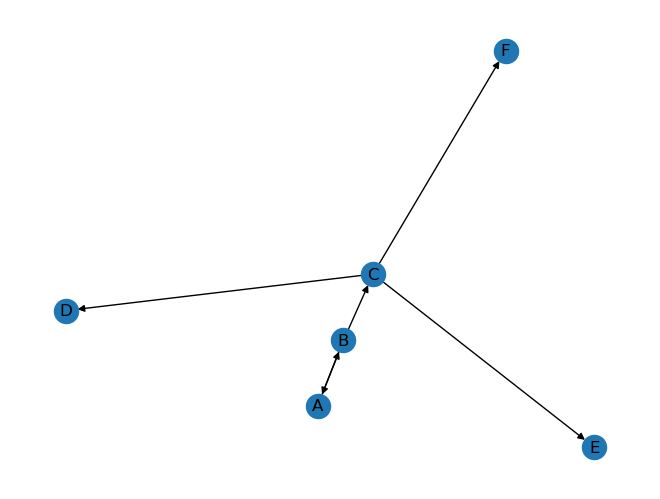

In [64]:
import matplotlib.pyplot as plt
nx.draw(U,with_labels=True)
plt.show()